# 模型建立与评估

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.font_manager as fm
import seaborn as sns
import warnings 

In [6]:
# 忽略警告
warnings.filterwarnings('ignore')
#添加字体配置
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  #"SimHei",
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常

In [3]:
# 高级数据处理与特征工程
class StockFeatureEngineer:
    """多因子数据处理与特征工程类"""
    def __init__(self, df):
        self.df = df.copy()
        self.base_features = [
            'macd', 'rsi10', 'mtm', 'bias5', 'volt20', 'mdd20',
            'pe', 'pb', 'ev', 'inc', 'return_', 'du', 'vol20', 'qtyr'
        ]
        self.engineered_features = []
    
    def preprocess_data(self):
        """数据预处理"""
        # 标记2024年12月的数据
        dec_2024_mask = (self.df['date'].dt.year == 2024) & (self.df['date'].dt.month == 12)
        dec_2024_factors = self.df[dec_2024_mask].copy()
        
        # 保存2024-12月的因子数据
        print(f"找到2024-12月的股票数据: {len(dec_2024_factors)}只股票")
        
        # 将2024-12-31的fwd_return设为NaN
        self.df.loc[dec_2024_mask, 'fwd_return'] = np.nan
        
        # 移除无效的收益率数据
        valid_df = self.df.dropna(subset=['fwd_return'])
        print(f"有效数据行数(有真实收益率的): {len(valid_df)}")
        
        return valid_df, dec_2024_factors
    
    def create_time_features(self):
        """创建时间特征，不依赖收益率的特征"""
        # 添加月份和季度特征
        self.df['month'] = self.df['date'].dt.month
        self.df['quarter'] = self.df['date'].dt.quarter
        self.engineered_features += ['month', 'quarter']
        
        # 添加季节性指标
        self.df['is_q4'] = (self.df['quarter'] == 4).astype(int)
        self.engineered_features.append('is_q4')
        
        return self
    
    def create_market_features(self):
        """创建市场整体特征"""
        # 市场波动率
        market_vol = self.df.groupby('date')['fwd_return'].std().reset_index()
        market_vol.columns = ['date', 'market_volatility']
        self.df = pd.merge(self.df, market_vol, on='date', how='left')
        self.engineered_features.append('market_volatility')
        
        # 市场收益率
        market_ret = self.df.groupby('date')['fwd_return'].mean().reset_index()
        market_ret.columns = ['date', 'market_return']
        self.df = pd.merge(self.df, market_ret, on='date', how='left')
        self.engineered_features.append('market_return')
        
        return self
    
    def create_stock_features(self):
        """创建个股特定特征，确保避免未来数据泄露"""
        # 排序确保时间序列正确
        self.df = self.df.sort_values(['code', 'date'])
        
        # 价格变化特征（仅使用当前和过去价格）
        self.df['price_change_1m'] = self.df.groupby('code')['close'].pct_change(1)
        self.engineered_features.append('price_change_1m')
        
        # 历史波动率
        self.df['volatility_6m'] = self.df.groupby('code')['price_change_1m'].transform(
            lambda x: x.rolling(6, min_periods=3).std())
        self.engineered_features.append('volatility_6m')
        
        # 相对强度指标
        self.df['relative_strength'] = self.df['rsi10'] / 100
        self.engineered_features.append('relative_strength')
        
        return self
    
    def create_interaction_features(self):
        """创建因子交互特征"""
        # PB与动量交互
        self.df['pb_mtm'] = self.df['pb'] * self.df['mtm']
        self.engineered_features.append('pb_mtm')
        
        # 波动率与MACD交互
        self.df['vol_macd'] = self.df['volt20'] * self.df['macd']
        self.engineered_features.append('vol_macd')
        
        # 价值与质量交互
        if 'pe' in self.base_features and 'pb' in self.base_features:
            self.df['value_quality'] = (self.df['pe'] + self.df['pb']) * self.df['qtyr']
            self.engineered_features.append('value_quality')
        
        return self
    
    def get_features(self):
        """获取最终特征列表"""
        # 合并所有特征
        all_features = self.base_features + self.engineered_features
        
        # 移除可能存在的重复
        all_features = list(set(all_features))
        
        print(f"创建了 {len(all_features)} 个特征")
        return self.df, all_features


In [4]:
class EnhancedStockModel:
    """多因子股票收益率预测模型（仅使用 XGBoost）"""
    def __init__(self, features):
        self.model = None
        self.features = features
    
    def train_model(self, train_df):
        """训练 XGBoost 模型"""
        X_train = train_df[self.features]
        y_train = train_df['fwd_return']
        
        self.model = XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        self.model.fit(X_train, y_train)
    
    def predict(self, X):
        """预测函数"""
        return self.model.predict(X)
    
    def evaluate(self, test_df):
        """评估模型性能"""
        X_test = test_df[self.features]
        y_test = test_df['fwd_return']
        
        y_pred = self.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        print("\n模型评估结果 (XGBoost):")
        print(f"MSE: {mse:.6f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        return mse, rmse, r2
    
    def plot_feature_importance(self):
        """绘制 XGBoost 特征重要性"""
        if self.model is not None:
            from xgboost import plot_importance
            plt.figure(figsize=(10, 6))
            plot_importance(self.model, max_num_features=20, title='XGBoost特征重要性')
            plt.tight_layout()
            plt.show()
        else:
            print("尚未训练模型，无法绘制特征重要性")
    
    def analyze_stock(self, test_df, stock_code='szse.000001'):
        """分析某只股票的表现"""
        if stock_code not in test_df['code'].values:
            print(f"警告: 数据集中没有股票 {stock_code}")
            return
        
        stock_test = test_df[test_df['code'] == stock_code].copy()
        X_stock = stock_test[self.features]
        stock_test['prediction'] = self.predict(X_stock)
        
        plt.figure(figsize=(14, 7))
        plt.plot(stock_test['date'], stock_test['fwd_return'], 'o-', label='实际收益率', linewidth=2.5)
        plt.plot(stock_test['date'], stock_test['prediction'], 's--', label='预测收益率', linewidth=2)
        
        max_error_idx = np.abs(stock_test['fwd_return'] - stock_test['prediction']).idxmax()
        plt.scatter(
            stock_test.loc[max_error_idx, 'date'],
            stock_test.loc[max_error_idx, 'fwd_return'],
            color='red', s=120, label='最大预测误差点'
        )
        
        plt.title(f'{stock_code} 实际vs预测收益率对比 (2024年)')
        plt.xlabel('日期')
        plt.ylabel('收益率')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xticks(rotation=35)
        plt.tight_layout()
        plt.savefig(f'{stock_code}_performance.png', dpi=300)
        plt.show()


增强型多因子选股策略

[阶段1] 加载数据...
原始数据大小: (18000, 20)

[阶段2] 数据处理与特征工程...
找到2024-12月的股票数据: 300只股票
有效数据行数(有真实收益率的): 17700
创建了 25 个特征

[阶段3] 数据准备...
训练集大小: (14400, 31), 时间段: 2020-01-23 - 2023-12-29
测试集大小: (3300, 31), 时间段: 2024-01-31 - 2024-11-29

[阶段4] 模型训练与评估...

模型评估结果 (XGBoost):
MSE: 0.010178
RMSE: 0.1009
R²: 0.2702


<Figure size 1000x600 with 0 Axes>

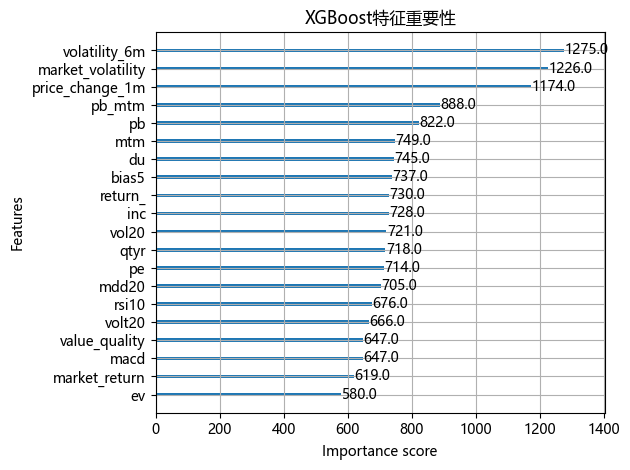


测试集预测结果已保存到 test_set_predictions.csv

[阶段5] 个股分析...


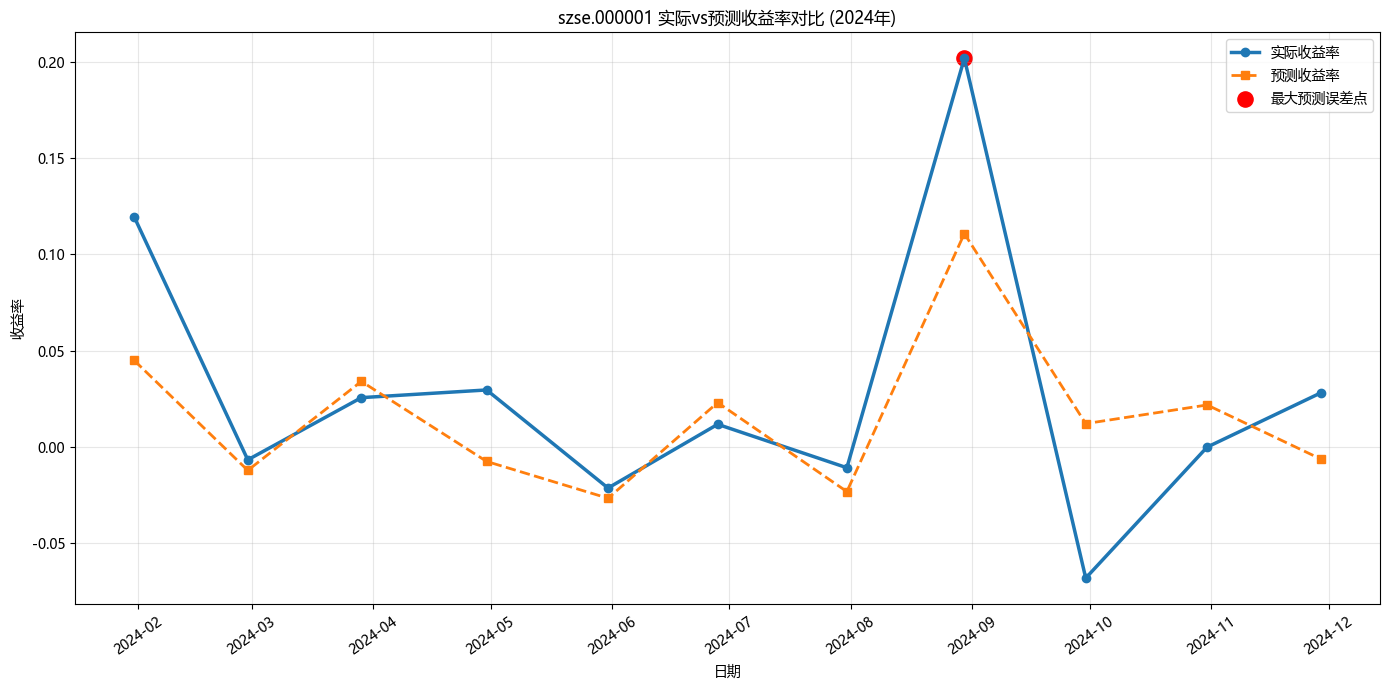


[阶段6] 2024年12月预测...

2024年12月31日收益率预测前10名:
              code  predicted_return
4499   szse.002475          0.053978
16199   sse.601828          0.050118
13199   sse.601012          0.047747
10319   sse.600438          0.043520
5399   szse.002841          0.040642
11219   sse.600606          0.035719
11159   sse.600588          0.034170
13379   sse.601066          0.032878
6419   szse.300144          0.032628
14219   sse.601216          0.032105


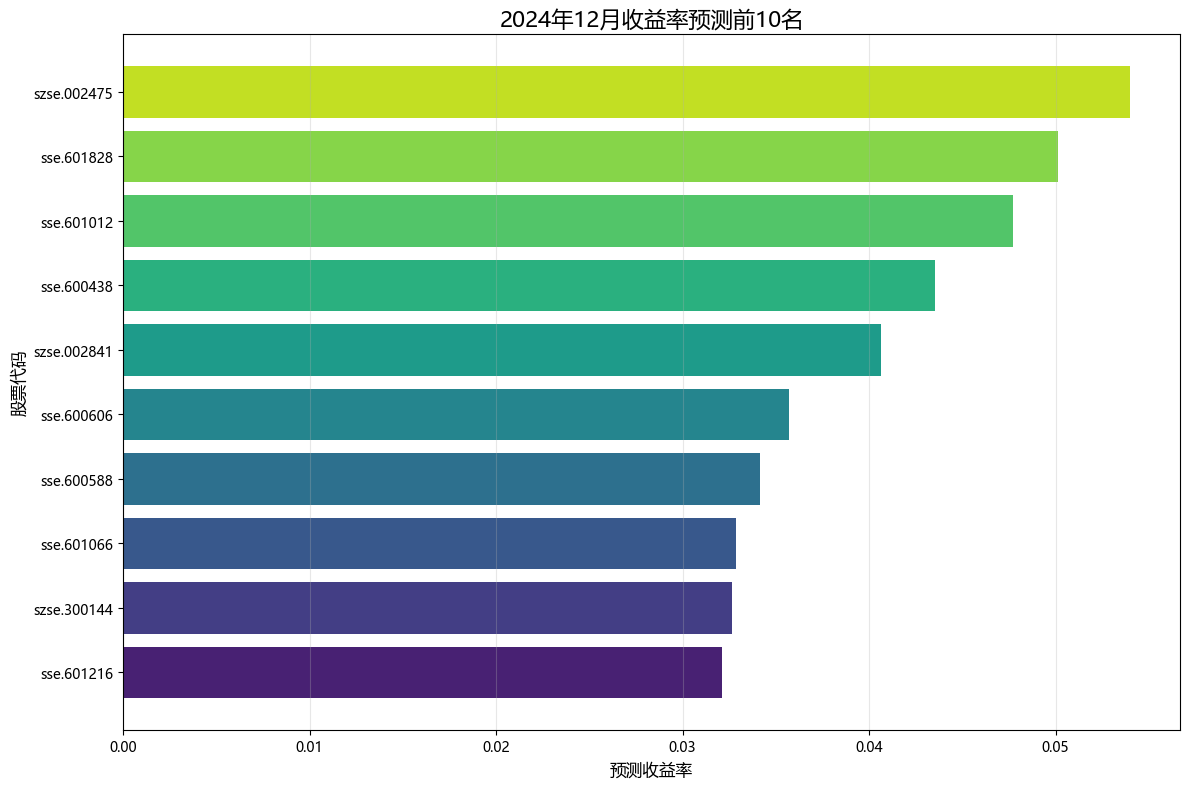

In [5]:
# 主流程
def main():
    print("=" * 70)
    print("增强型多因子选股策略")
    print("=" * 70)
    
    try:
        # 1. 加载数据
        print("\n[阶段1] 加载数据...")
        df = pd.read_csv('merged_data.csv', parse_dates=['date'])
        print(f"原始数据大小: {df.shape}")
        
        # 2. 数据预处理与特征工程
        print("\n[阶段2] 数据处理与特征工程...")
        engineer = StockFeatureEngineer(df)
        valid_df, dec_2024_factors = engineer.preprocess_data()
        engineer.create_time_features()
        engineer.create_market_features()
        engineer.create_stock_features()
        engineer.create_interaction_features()
        final_df, features = engineer.get_features()
        
        # 3. 数据准备（时序分割）
        print("\n[阶段3] 数据准备...")
        train_df = final_df[final_df['date'] < '2024-01-01']
        test_df = final_df[(final_df['date'] >= '2024-01-01') & 
                          (final_df['date'] < '2024-12-01')]
        
        print(f"训练集大小: {train_df.shape}, 时间段: {train_df['date'].min().date()} - {train_df['date'].max().date()}")
        print(f"测试集大小: {test_df.shape}, 时间段: {test_df['date'].min().date()} - {test_df['date'].max().date()}")
        
        # 4. 模型训练与评估
        print("\n[阶段4] 模型训练与评估...")
        model = EnhancedStockModel(features)
        model.train_model(train_df)
        mse, rmse, r2 = model.evaluate(test_df)
        model.plot_feature_importance()

        # 保存测试集预测结果
        X_test = test_df[features]
        test_pred = model.predict(X_test)
        test_result_df = test_df[['date', 'code', 'fwd_return']].copy()
        test_result_df['prediction'] = test_pred
        test_result_df = test_result_df[['date', 'code', 'prediction', 'fwd_return']]
        test_result_df.to_csv('test_set_predictions.csv', index=False)
        print("\n测试集预测结果已保存到 test_set_predictions.csv")

        # 5. 个股分析
        print("\n[阶段5] 个股分析...")
        model.analyze_stock(test_df)
        
        # 6. 2024-12预测
        print("\n[阶段6] 2024年12月预测...")
        if not dec_2024_factors.empty:
            # 为预测数据添加必要的特征
            dec_2024 = dec_2024_factors.copy()
            
            # 添加时间特征
            dec_2024['month'] = dec_2024['date'].dt.month
            dec_2024['quarter'] = dec_2024['date'].dt.quarter
            dec_2024['is_q4'] = (dec_2024['quarter'] == 4).astype(int)
            
            # 添加市场特征（使用整体市场平均值）
            for market_feat in ['market_volatility', 'market_return']:
                if market_feat in train_df.columns:
                    dec_2024[market_feat] = train_df[market_feat].mean()
            
            # 添加其他特征（用历史平均值）
            for feat in features:
                if feat not in dec_2024.columns and feat in train_df.columns:
                    dec_2024[feat] = train_df[feat].mean()
            
            # 确保特征存在
            available_features = [f for f in features if f in dec_2024.columns]
            
            # 预测收益率
            predictions = model.predict(dec_2024[available_features])
            dec_2024['predicted_return'] = predictions
            
            # 筛选前10名
            top_10 = dec_2024.nlargest(10, 'predicted_return')[['code', 'predicted_return']]
            
            # 打印结果
            print("\n2024年12月31日收益率预测前10名:")
            print(top_10)
            
            # 可视化结果
            plt.figure(figsize=(12, 8))
            plt.barh(
                y=top_10['code'].astype(str)[::-1],  # 反转使第一名在最上方
                width=top_10['predicted_return'][::-1],
                color=sns.color_palette("viridis", len(top_10))
            )
            plt.title('2024年12月收益率预测前10名', fontsize=16)
            plt.xlabel('预测收益率', fontsize=12)
            plt.ylabel('股票代码', fontsize=12)
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            #plt.savefig('2024_top10_stocks.png', dpi=300)
            plt.show()
            
            # 保存结果
            #dec_2024[['code', 'date', 'predicted_return']].to_csv('2024_dec_predictions.csv', index=False)
    except Exception as e:
        print(f"发生错误: {str(e)}")

if __name__ == "__main__":
    main()

In [4]:
# 保存股票预测数据
df = pd.read_csv('test_set_predictions.csv') # 读取数据（包含表头）
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d') # 将date列转换为日期格式
sorted_df = df.sort_values(by=['date', 'prediction'], ascending=[True, False]) # 按date升序，prediction降序排序
top10_df = sorted_df.groupby('date').head(10) # 对每个日期保留prediction值前10的股票
top10_df.to_csv('top10_predictions.csv', index=False) # 保存结果

# 查看结果
print(top10_df.dtypes)  # 验证date列已转换为datetime格式
print(top10_df.head())

date          datetime64[ns]
code                  object
prediction           float64
fwd_return           float64
dtype: object
           date         code  prediction  fwd_return
3245 2024-01-31  szse.300347    0.278544    0.109606
770  2024-01-31   sse.600570    0.270292    0.160646
3047 2024-01-31  szse.002841    0.231554    0.145359
3058 2024-01-31  szse.002916    0.198796    0.328288
2013 2024-01-31   sse.603799    0.191464    0.111557
